# EKF — Per-Motor Current Prediction (Power Limiter / TV)

| Property | Value |
|----------|-------|
| **Models** | 4 × EKF (state: I_m, dI/dt, P_mech_m) |
| **Baseline** | 4-motor Linear KF (Constant Velocity) |
| **Input** | P_mech_m = |T_m|·|v_m|, U_dc |
| **Output** | I_FL, I_FR, I_RL, I_RR at t+1 |
| **Data** | training_data.csv — 5 Hz, split by run_id |

**Why EKF:** the Jacobian F contains γ·dt/U_dc(t) — this term changes each tick
as battery voltage varies with SoC, making the model a genuine Extended Kalman Filter.

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path().resolve()
SRC_DIR  = _cwd if (_cwd / 'functions').exists() else _cwd / 'src'
DATA_DIR = SRC_DIR.parent / 'data' / 'model'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DT            = 0.2        # 5 Hz sample rate
N_LAGS        = 5          # 1 s lookback (5 ticks × 0.2 s)
POWER_LIMIT_W = 80_000
MOTOR_NAMES   = ['FL', 'FR', 'RL', 'RR']
from scipy.signal import correlate
from sklearn.linear_model import LinearRegression
from functions.ekf_nonlinear import make_power_ekf
from functions.kalman_filter import make_constant_velocity_kf
from functions.evaluation    import display_model_results, compare_models

U_MIN = 350.0   # clamp voltage in Jacobian to avoid division by zero
print(f'DATA_DIR : {DATA_DIR}')


DATA_DIR : /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/data/model


## 1. Data Loading

In [2]:
df = pd.read_csv(DATA_DIR / 'training_data.csv')
df = df.sort_values(['run_id', 'timestamp_s']).reset_index(drop=True)

# Mechanical power proxy per motor: |torque| * |velocity|
for m in MOTOR_NAMES:
    df[f'P_mech_{m}'] = df[f'T_{m}'].abs() * df[f'v_{m}'].abs()

# 1-step-ahead target within each run
for m in MOTOR_NAMES:
    df[f'I_{m}_next'] = df.groupby('run_id')[f'I_{m}'].shift(-1)

df_clean = df.dropna().reset_index(drop=True)

runs         = sorted(df_clean['run_id'].unique())
n_train_runs = max(1, int(len(runs) * 0.70))
train_runs   = runs[:n_train_runs]
test_runs    = runs[n_train_runs:]

df_train = df_clean[df_clean['run_id'].isin(train_runs)].reset_index(drop=True)
df_test  = df_clean[df_clean['run_id'].isin(test_runs)].reset_index(drop=True)

y_test  = df_test[[f'I_{m}_next' for m in MOTOR_NAMES]].values
U_dcv   = np.maximum(df_test['U_dc'].values, U_MIN)
t_test  = df_test['timestamp_s'].values

print(f'Train : {train_runs}  ({len(df_train):,} samples)')
print(f'Test  : {test_runs}   ({len(df_test):,} samples)')
print(f'U_dc  : {df_clean["U_dc"].min():.1f} – {df_clean["U_dc"].max():.1f} V')


Train : [2, 3, 4, 5, 6, 7, 8]  (3,765 samples)
Test  : [9, 10, 11]   (1,918 samples)
U_dc  : 498.4 – 571.9 V


## 2. Parameter Estimation

Cross-correlate training data to find response lags τ_motor and τ_mech.

tau_motor : 0.20 s  (peak_T = 1)
tau_mech  : 0.20 s  (peak_P = 1)
gamma     : 5.000 1/s  |  alpha : 1.0000
k_p       : 1.30303  |  R_std : 710.73 A


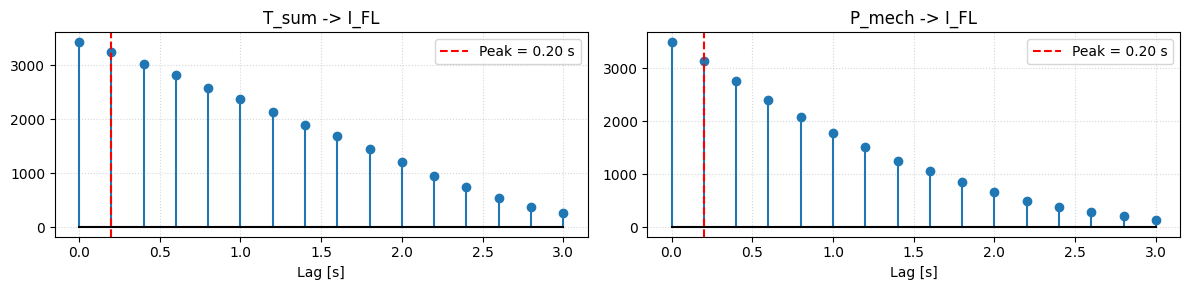

In [3]:
MAX_LAG = 15   # at 5 Hz: 15 lags = 3 s

I_tr = df_train['I_FL'].values
T_tr = (df_train['T_FL'] + df_train['T_FR'] + df_train['T_RL'] + df_train['T_RR']).values
P_tr = df_train['P_mech_FL'].values
U_tr = np.maximum(df_train['U_dc'].values, U_MIN)

def _norm(x): return (x - x.mean()) / (x.std() + 1e-8)

mid  = len(I_tr) - 1
xc_T = correlate(_norm(I_tr), _norm(T_tr), mode='full')[mid:mid + MAX_LAG + 1]
xc_P = correlate(_norm(I_tr), _norm(P_tr), mode='full')[mid:mid + MAX_LAG + 1]

peak_T    = max(int(np.argmax(xc_T)), 1)
peak_P    = max(int(np.argmax(xc_P)), 1)
tau_motor = peak_T * DT
tau_mech  = peak_P * DT
gamma     = min(1.0 / max(tau_motor, DT), 1.0 / DT)   # clamp: ensure 1-γ·dt ≥ 0
alpha_ekf = min(DT / max(tau_mech, DT), 1.0)

# k_p: scale P_mech to current units
mask = (I_tr > 20) & (T_tr > 50)
if mask.sum() > 50:
    X_kp = (P_tr[mask] / U_tr[mask]).reshape(-1, 1)
    k_p  = float(LinearRegression(fit_intercept=False).fit(X_kp, I_tr[mask]).coef_[0])
    k_p  = max(k_p, 1e-6)
else:
    k_p = 1.0

I_smooth = pd.Series(I_tr).rolling(3, center=True, min_periods=1).median().values
R_std    = max(float(np.std(I_tr - I_smooth)), 1.0)
q_accel  = max(float(np.percentile(np.abs(np.diff(I_tr, n=2) / DT**2), 75)), 1.0)
q_Pm     = max(float(np.std(np.diff(P_tr * k_p))), 1.0)

print(f'tau_motor : {tau_motor:.2f} s  (peak_T = {peak_T})')
print(f'tau_mech  : {tau_mech:.2f} s  (peak_P = {peak_P})')
print(f'gamma     : {gamma:.3f} 1/s  |  alpha : {alpha_ekf:.4f}')
print(f'k_p       : {k_p:.5f}  |  R_std : {R_std:.2f} A')

lags = np.arange(MAX_LAG + 1) * DT
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, xc, label, pk in [(axes[0], xc_T, 'T_sum -> I_FL', peak_T),
                           (axes[1], xc_P, 'P_mech -> I_FL', peak_P)]:
    ax.stem(lags, xc, markerfmt='C0o', linefmt='C0-', basefmt='k-')
    ax.axvline(pk * DT, color='red', ls='--', label=f'Peak = {pk * DT:.2f} s')
    ax.set_xlabel('Lag [s]'); ax.set_title(label); ax.legend()
    ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()


## 3. Build Filters

In [4]:
ekfs = {}
for m in MOTOR_NAMES:
    I0_m    = float(df_test[f'I_{m}'].iloc[0])
    Pm0_m   = k_p * float(df_test[f'P_mech_{m}'].iloc[0])
    ekfs[m] = make_power_ekf(
        dt=DT, gamma=gamma, alpha=alpha_ekf,
        q_I=R_std, q_dI=q_accel*DT, q_Pm=q_Pm,
        r_noise=R_std, I0=I0_m, P_mech0=Pm0_m,
    )

I0_all = np.array([df_test[f'I_{m}'].iloc[0] for m in MOTOR_NAMES])
kf_cv  = make_constant_velocity_kf(
    dt=DT, r_noise=R_std, q_accel=q_accel, n_motors=4,
    x0=np.kron(I0_all, [1.0, 0.0]),
)
ci_cv = kf_cv.current_indices(n_motors=4)
print('EKF states:', {m: np.round(ekfs[m].state, 1) for m in MOTOR_NAMES})
print('CV state dim:', kf_cv.F.shape[0], '  current indices:', ci_cv)


EKF states: {'FL': array([409.,   0.,   0.]), 'FR': array([481.,   0.,   0.]), 'RL': array([873.,   0.,   0.]), 'RR': array([755.,   0.,   0.])}
CV state dim: 8   current indices: [0, 2, 4, 6]


## 4. Simulation Loop

In [5]:
N       = len(df_test)
pred_ekf = np.zeros((N, 4))
pred_cv  = np.zeros((N, 4))
std_ekf  = np.zeros((N, 4))
I_meas   = np.column_stack([df_test[f'I_{m}'].values for m in MOTOR_NAMES])

t0 = time.perf_counter()
for i in range(N):
    U_i = float(U_dcv[i])

    x_cv       = kf_cv.predict_k_ahead(k=1)
    pred_cv[i] = x_cv[ci_cv]
    kf_cv.predict()
    kf_cv.update(I_meas[i])

    for j, m in enumerate(MOTOR_NAMES):
        P_i            = k_p * float(df_test[f'P_mech_{m}'].iloc[i])
        xa             = ekfs[m].predict_k_ahead(k=1, P_input_seq=[P_i], U_dc_seq=[U_i])
        pred_ekf[i, j] = xa[0]
        std_ekf[i, j]  = ekfs[m].estimate_std()[0]
        ekfs[m].predict(P_input=P_i, U_dc=U_i)
        ekfs[m].update(I_meas[i, j])

t_sim = time.perf_counter() - t0
print(f'Simulation: {N:,} ticks  {t_sim*1000:.1f} ms  ({t_sim/N*1e6:.1f} us/tick)')


Simulation: 1,918 ticks  729.7 ms  (380.5 us/tick)


## 5. Evaluation

  MODEL: KF CV 4-motor
  R2              : -0.1075
  RMSE            : 9296.28 A
  MAE             : 3817.08 A
  MedAE           : 458.13 A
  MAPE            : 150.57 %
  R2 per motor    : FL=-0.075  FR=-0.042  RL=-0.205  RR=-0.073
--------------------------------------------------------
  Under-pred.     : 54.2 % of samples
  Mean under-pred.: 3523.99 A   (dangerous direction!)
--------------------------------------------------------
  Power RMSE      : 17864.79 kW
  Real violations : 1918 events > 80 kW
  Missed (FN)     : 183   <- CRITICAL
  Unnecessary (FP): 0
  Violation recall: 90.5 %
--------------------------------------------------------
  Time/sample     : 0.3805 ms
  Frequency       : 2628.5 Hz



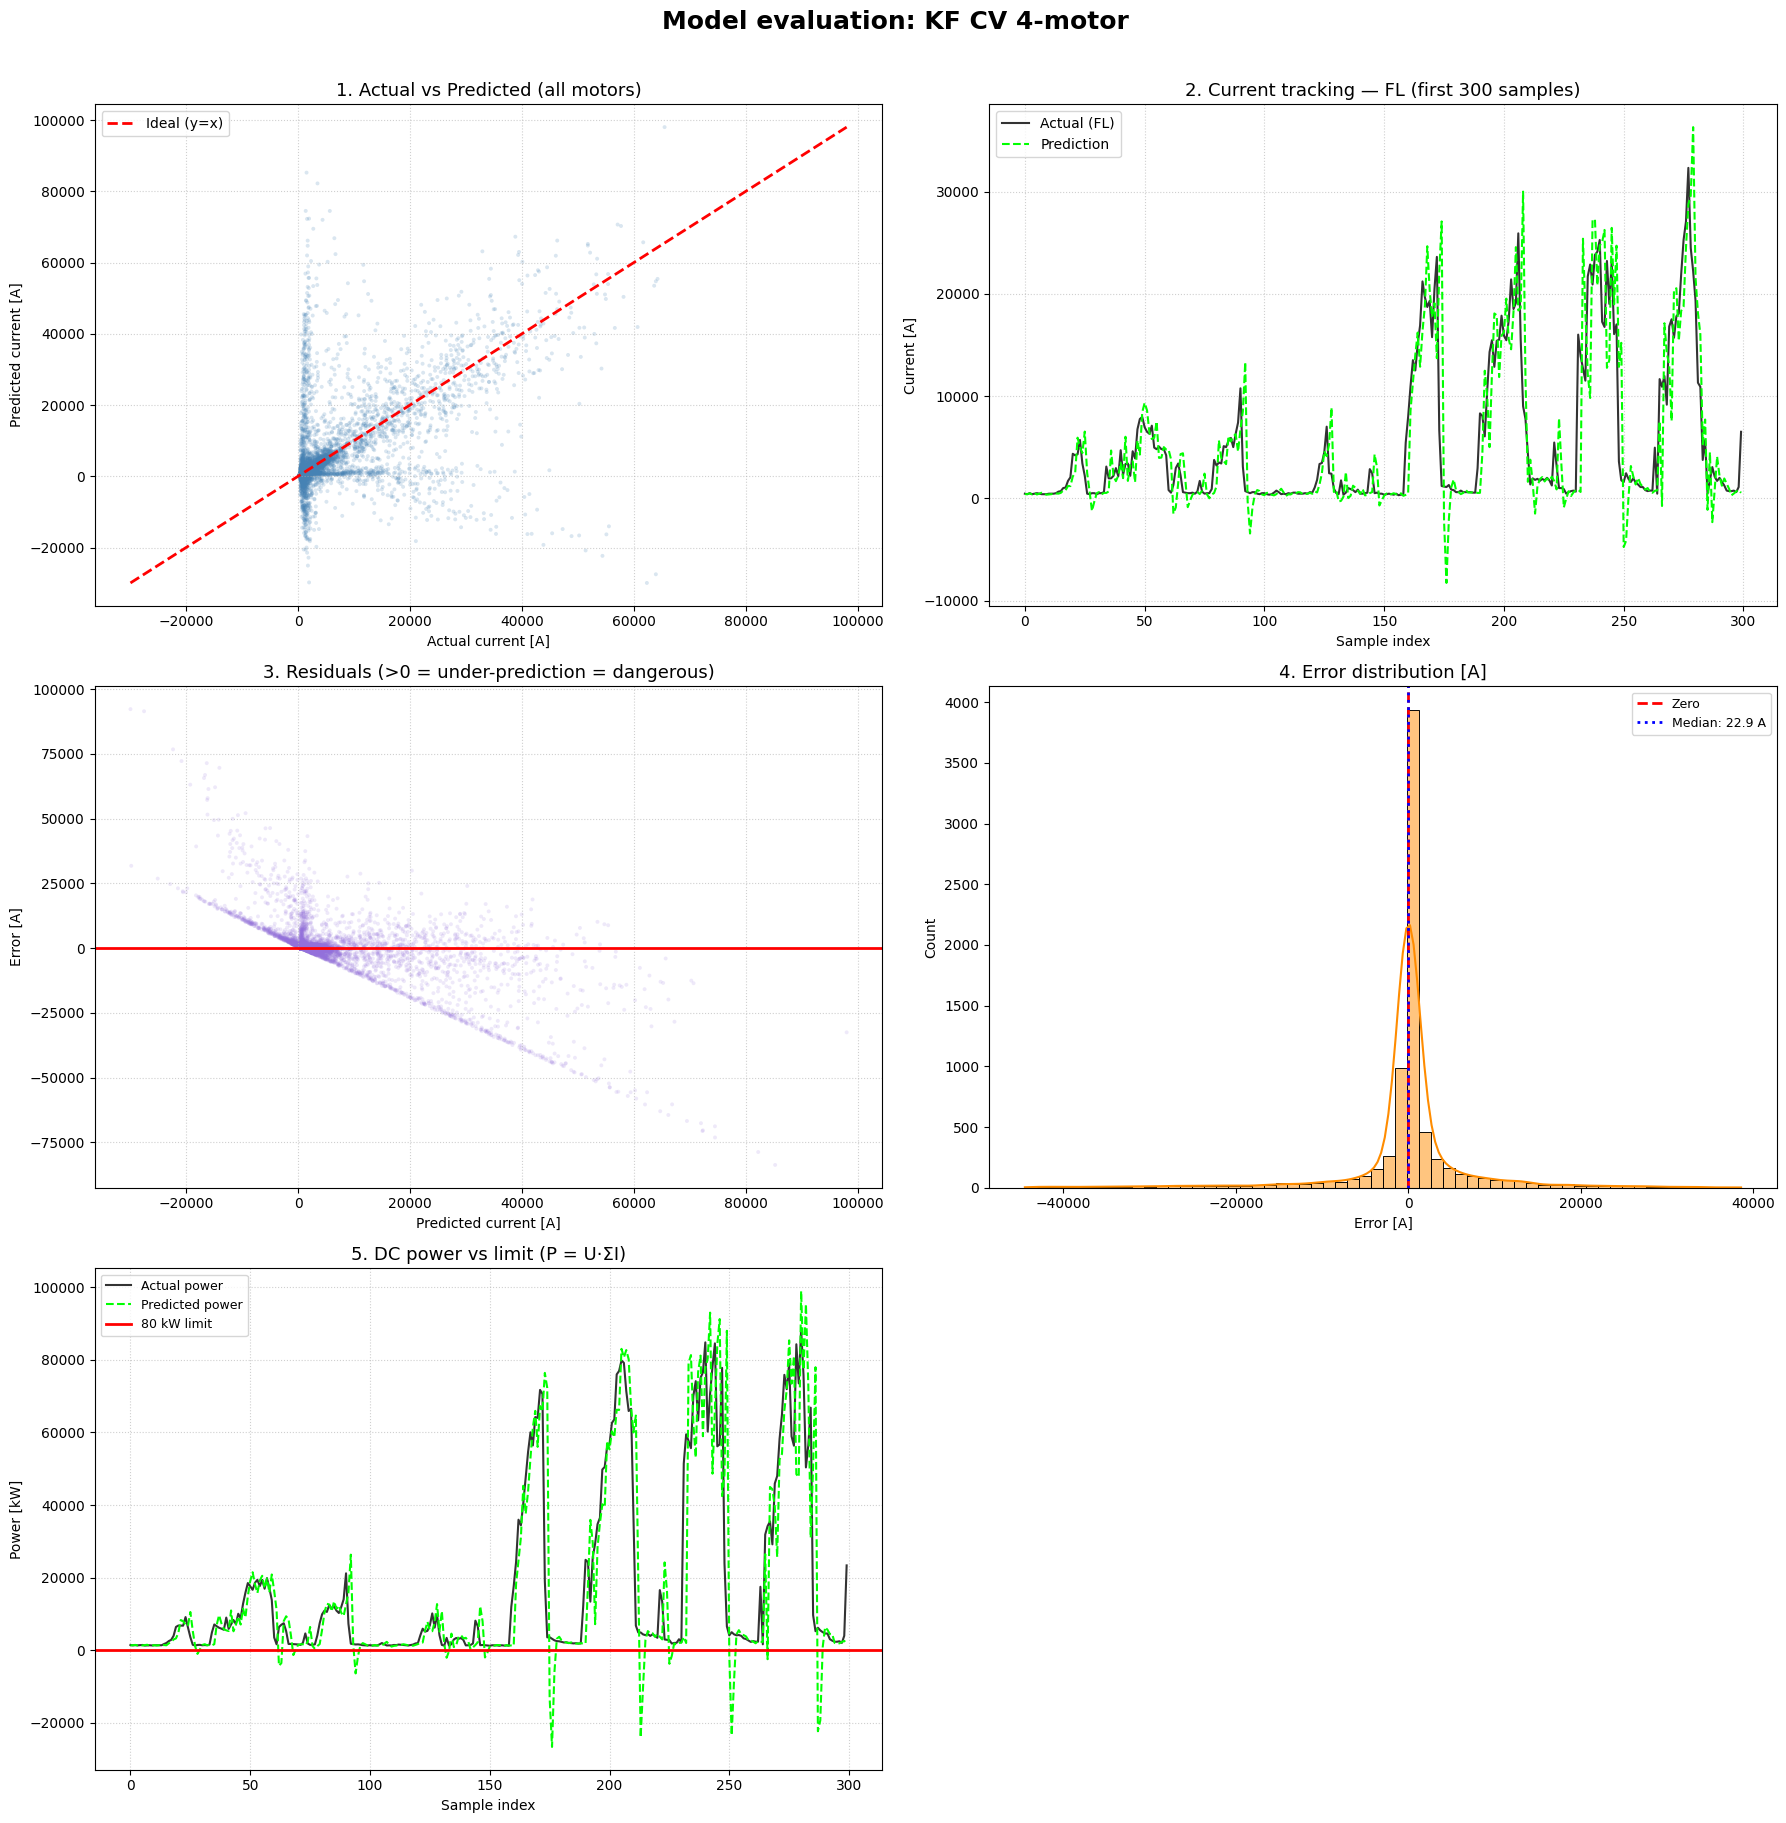

  MODEL: EKF 3-state 4-motor
  R2              : 0.4157
  RMSE            : 6752.52 A
  MAE             : 3032.97 A
  MedAE           : 354.96 A
  MAPE            : 101.18 %
  R2 per motor    : FL=0.390  FR=0.427  RL=0.389  RR=0.424
--------------------------------------------------------
  Under-pred.     : 78.6 % of samples
  Mean under-pred.: 2366.19 A   (dangerous direction!)
--------------------------------------------------------
  Power RMSE      : 13134.57 kW
  Real violations : 1918 events > 80 kW
  Missed (FN)     : 0   <- CRITICAL
  Unnecessary (FP): 0
  Violation recall: 100.0 %
--------------------------------------------------------
  Time/sample     : 0.3805 ms
  Frequency       : 2628.5 Hz

  [Excel] Result added → /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/src/model_results.xlsx



/home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/src/functions/evaluation.py:128: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


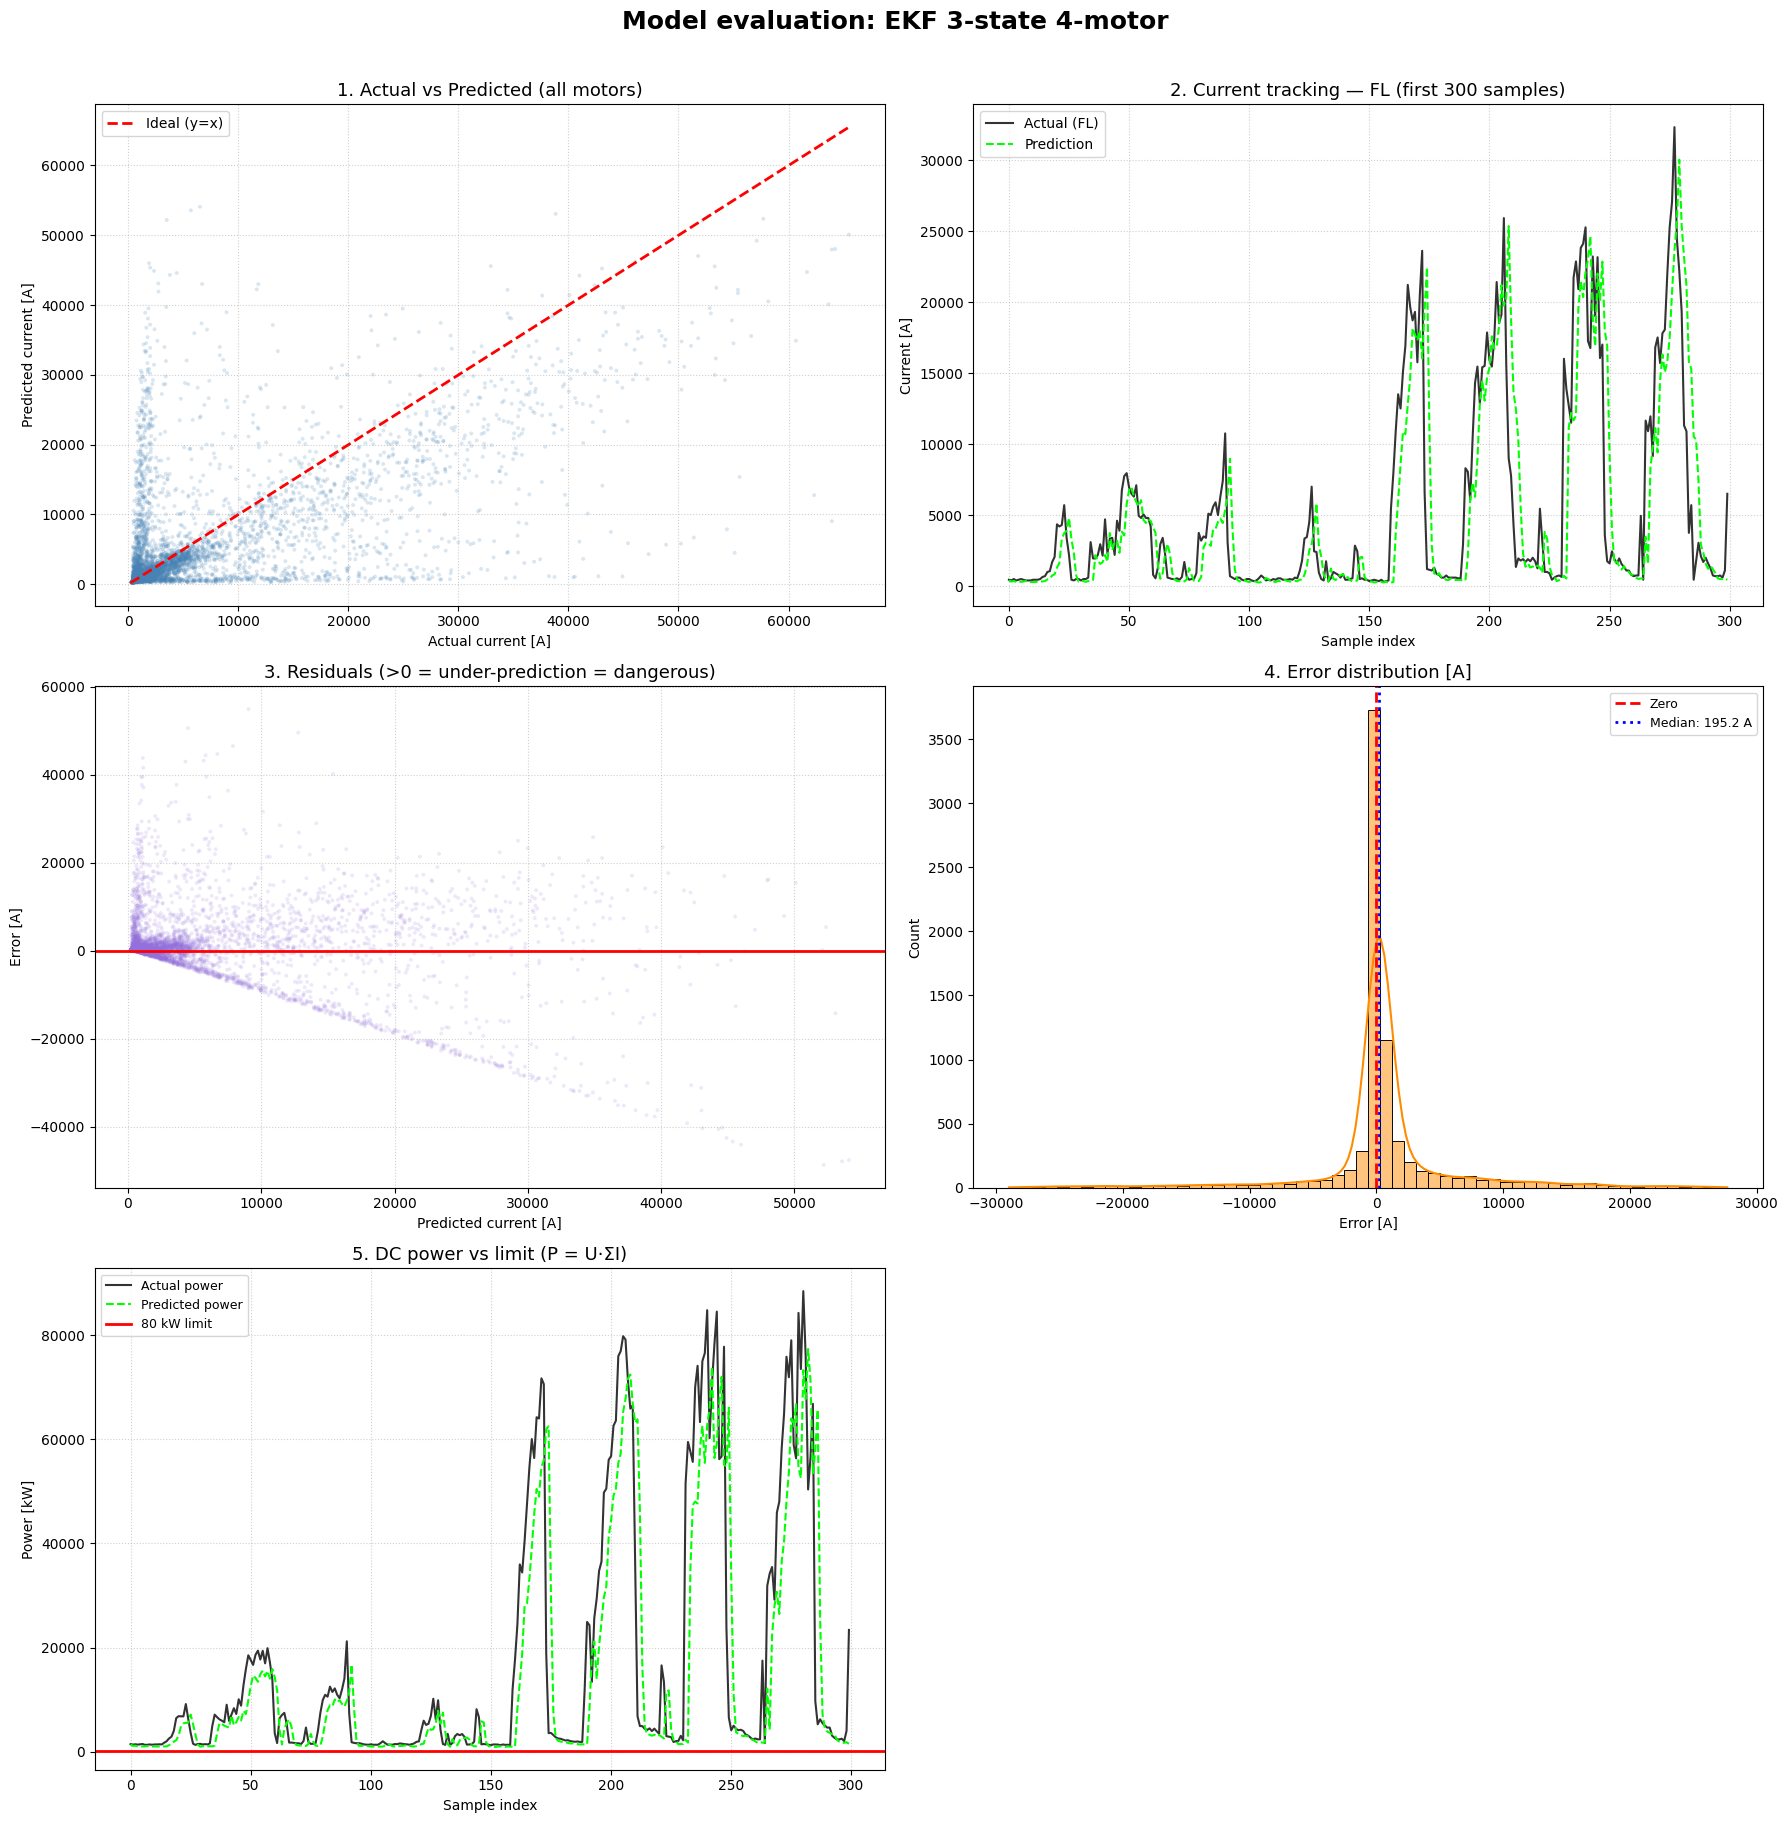


  MODEL COMPARISON
                        R2  RMSE [A]  MAE [A]  MedAE [A]  MAPE [%]  Underpred. [%]  Mean underpred. [A]  ms/sample  Freq. [Hz]  R2_FL  R2_FR  R2_RL  R2_RR  Power RMSE [kW]  Violations [n]  FN (missed)  FP (unnecessary)  Violation recall [%]
model                                                                                                                                                                                                                                           
EKF 3-state 4-motor  0.416  6752.519 3032.968    354.963   101.183          78.624             2366.191      0.380    2628.459  0.390  0.427  0.389  0.424        13134.573            1918            0                 0               100.000
KF CV 4-motor       -0.107  9296.277 3817.076    458.128   150.569          54.158             3523.987      0.380    2628.459 -0.075 -0.042 -0.205 -0.073        17864.792            1918          183                 0                90.459



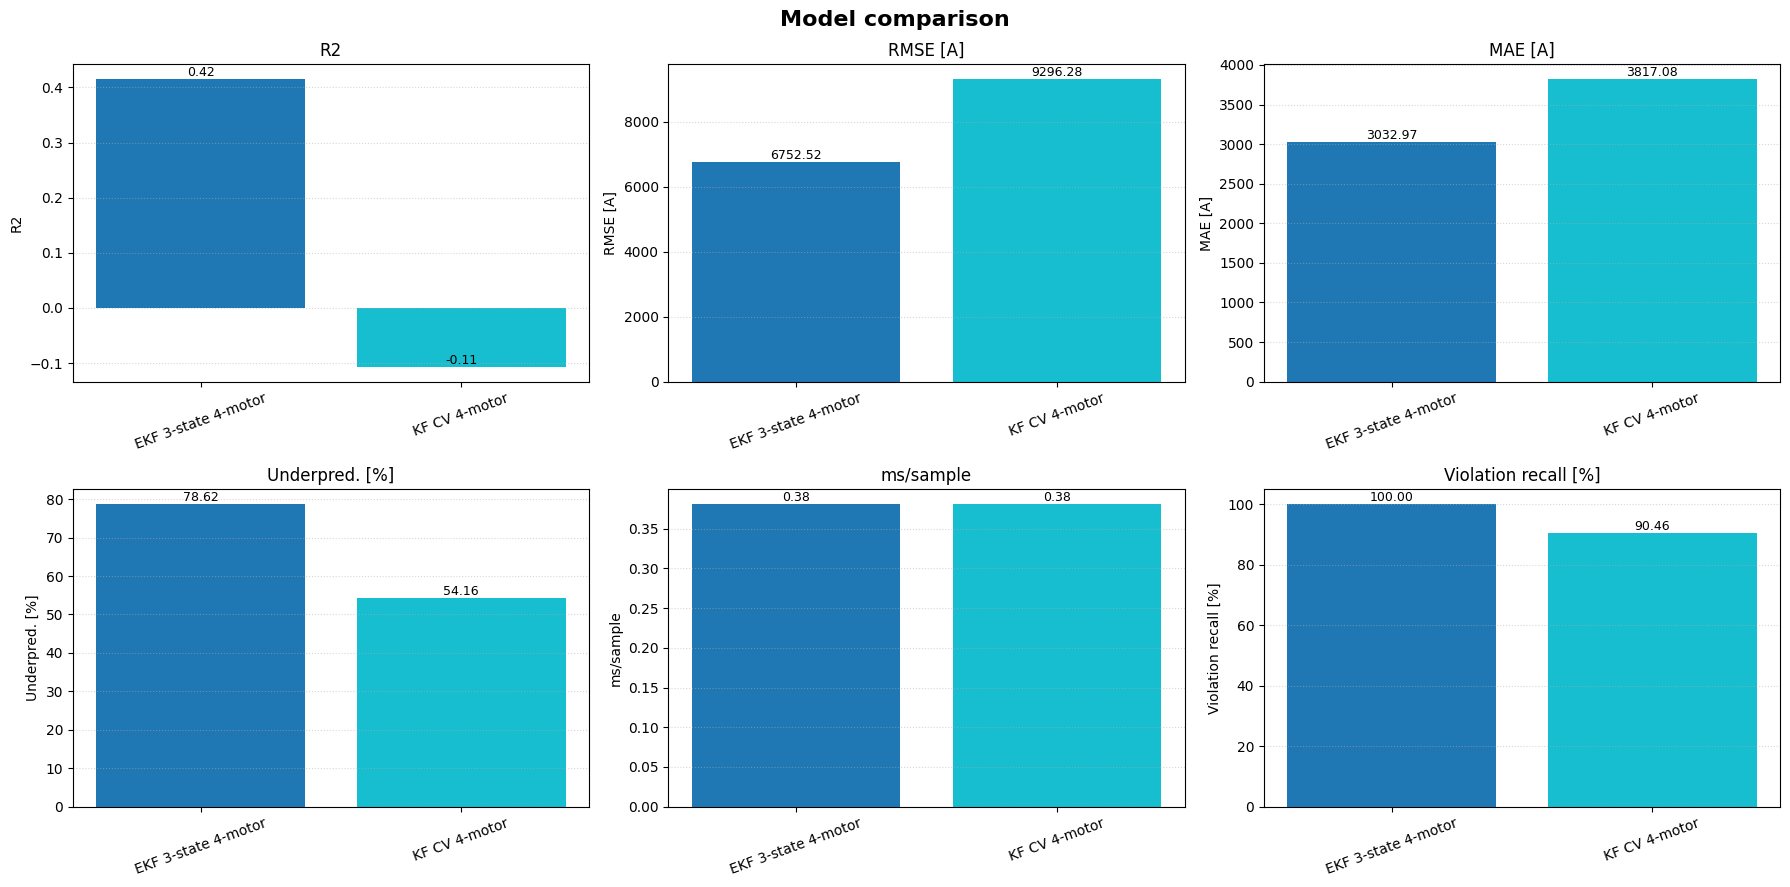

,R2,RMSE [A],MAE [A],MedAE [A],MAPE [%],Underpred. [%],Mean underpred. [A],ms/sample,Freq. [Hz],R2_FL,R2_FR,R2_RL,R2_RR,Power RMSE [kW],Violations [n],FN (missed),FP (unnecessary),Violation recall [%]
model,,,,,,,,,,,,,,,,,,
EKF 3-state 4-motor,0.415693,6752.519144,3032.967714,354.963276,101.182558,78.623566,2366.190902,0.380451,2628.458556,0.389642,0.426543,0.389348,0.423902,13134.572831,1918,0,0,100.000000
KF CV 4-motor,-0.107458,9296.276724,3817.076006,458.127969,150.568842,54.157977,3523.986891,0.380451,2628.458556,-0.074876,-0.041518,-0.205368,-0.073336,17864.791921,1918,183,0,90.458811


In [6]:
m_cv = display_model_results(
    'KF CV 4-motor', y_test, pred_cv,
    t_sim, voltage=U_dcv, motor_names=MOTOR_NAMES, save_to_excel=False,
)
m_ekf = display_model_results(
    'EKF 3-state 4-motor', y_test, pred_ekf,
    t_sim, voltage=U_dcv, motor_names=MOTOR_NAMES, save_to_excel=True,
)
compare_models([m_cv, m_ekf], sort_by='RMSE [A]')


## 6. Visualization

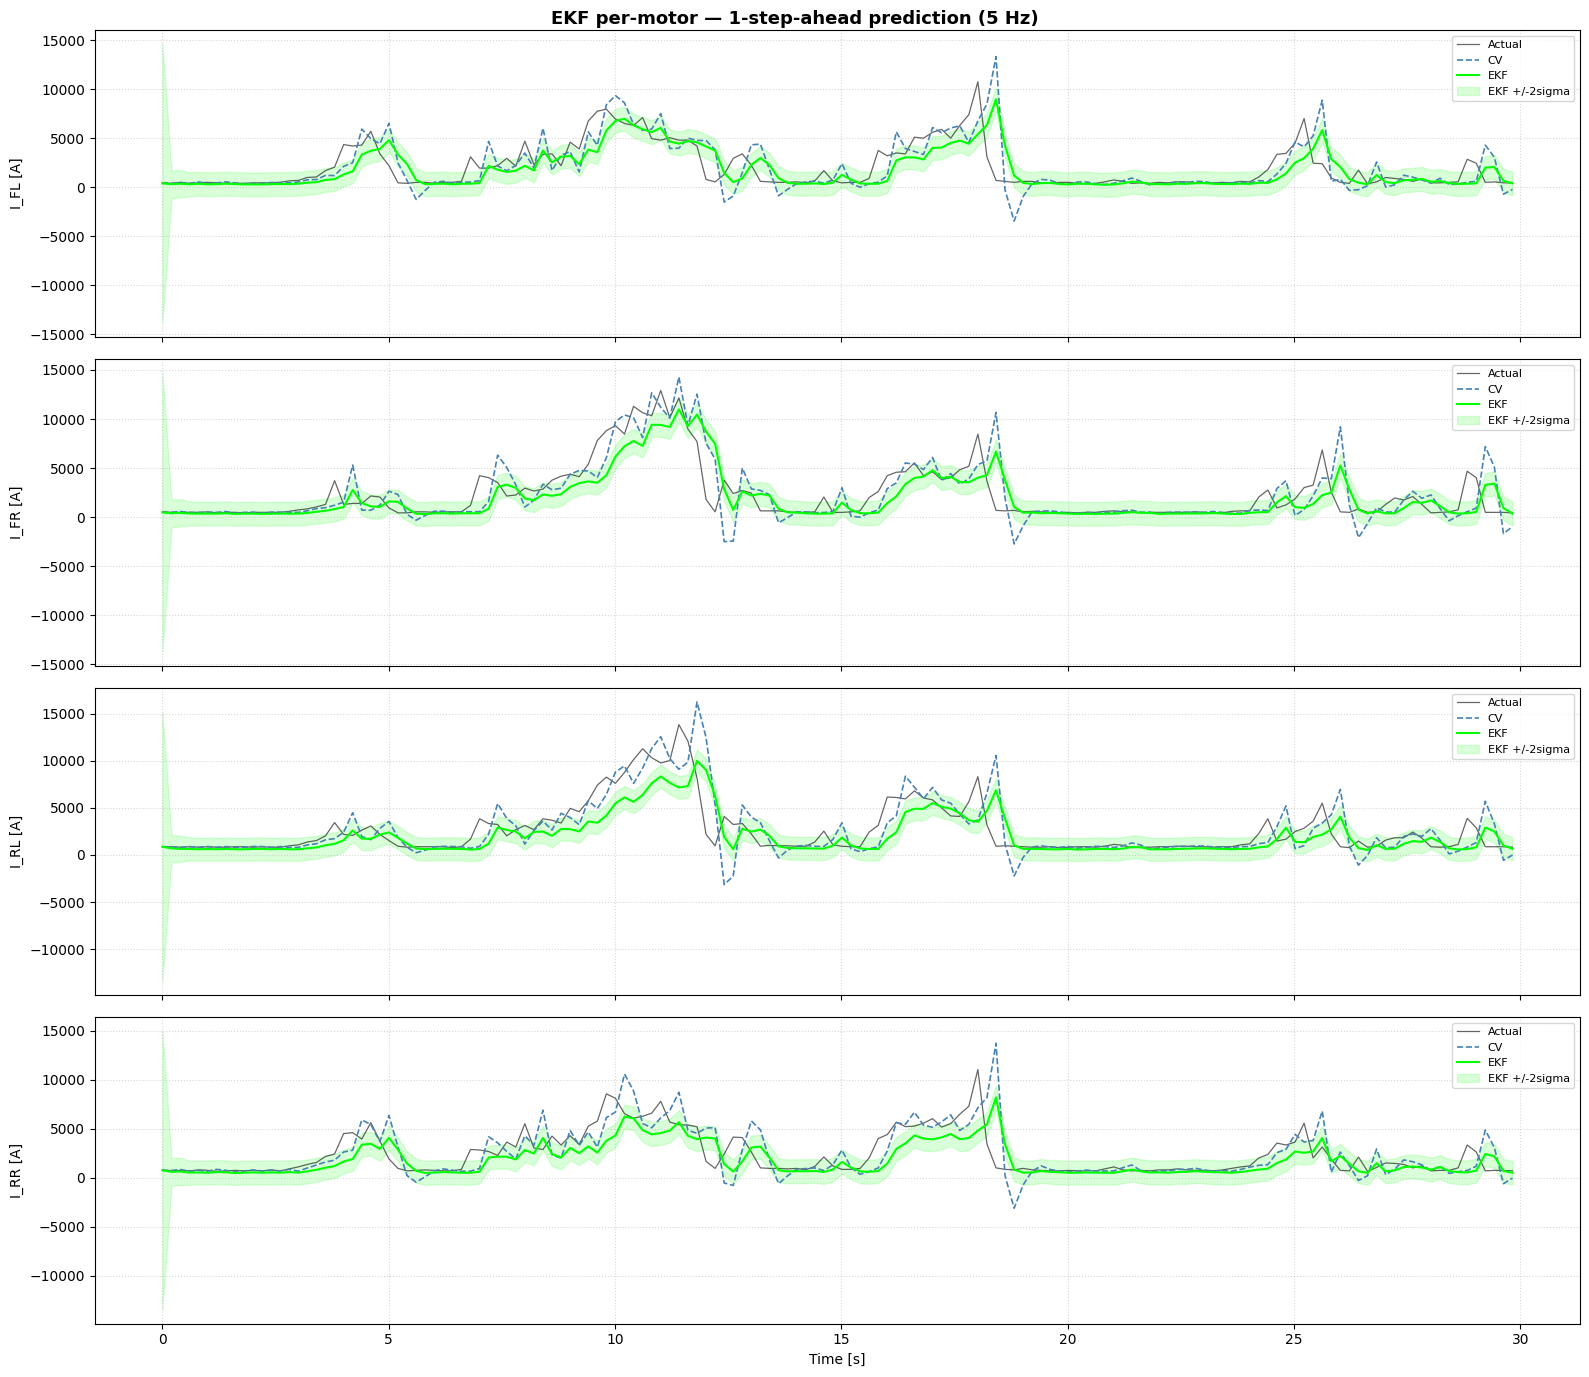

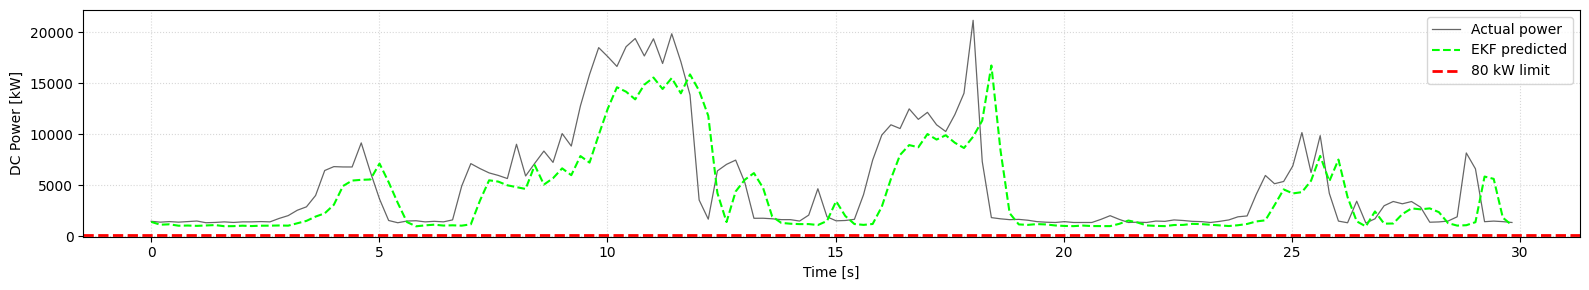

In [7]:
N_PLOT = min(150, N)
sl     = slice(0, N_PLOT)
t_pl   = t_test[sl] - t_test[0]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('EKF per-motor — 1-step-ahead prediction (5 Hz)', fontsize=13, fontweight='bold')
for i, (ax, m) in enumerate(zip(axes, MOTOR_NAMES)):
    ax.plot(t_pl, y_test[sl, i],     lw=0.9, color='black',     alpha=0.6, label='Actual')
    ax.plot(t_pl, pred_cv[sl, i],    lw=1.2, color='steelblue', ls='--',   label='CV')
    ax.plot(t_pl, pred_ekf[sl, i],   lw=1.5, color='lime',                 label='EKF')
    ax.fill_between(t_pl,
                    pred_ekf[sl, i] - 2*std_ekf[sl, i],
                    pred_ekf[sl, i] + 2*std_ekf[sl, i],
                    alpha=0.15, color='lime', label='EKF +/-2sigma')
    ax.set_ylabel(f'I_{m} [A]'); ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.5)
axes[-1].set_xlabel('Time [s]')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(16, 3))
P_true = U_dcv[sl] * y_test[sl].sum(axis=1) / 1e3
P_ekf  = U_dcv[sl] * pred_ekf[sl].sum(axis=1) / 1e3
ax.plot(t_pl, P_true, lw=0.9, color='black', alpha=0.6, label='Actual power')
ax.plot(t_pl, P_ekf,  lw=1.5, color='lime',  ls='--',  label='EKF predicted')
ax.axhline(POWER_LIMIT_W / 1e3, color='red', lw=2, ls='--', label='80 kW limit')
ax.set_ylabel('DC Power [kW]'); ax.set_xlabel('Time [s]')
ax.legend(); ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()
